# Chapter 5: Critical Thinking → Ethical AI & Bias Auditing
## PhishShield — Bias & Fairness Analysis

This notebook is the executable companion to **Chapter 5: Critical Thinking, Ethical AI & Bias Auditing**.

### Deliverable
**Bias & Fairness Analysis** section for the final report, supported by reproducible code and saved audit artifacts.

### Scope
This notebook evaluates:

1. **Model explanations**
   - SHAP
   - LIME
   - Partial Dependence Plots (PDP)
   - Individual Conditional Expectation (ICE)
   - model-based / permutation importance

2. **Model limitations**
   - class imbalance
   - leakage risk
   - overfitting
   - feature/deployment mismatch
   - concept drift indicators

3. **Bias and fairness auditing**
   - checks whether demographic sensitive attributes exist
   - if absent, explicitly documents that demographic fairness cannot be evaluated
   - audits meaningful **operational subgroups** instead:
     - common vs rare TLDs
     - short vs long URLs
     - IP vs named domains
     - HTTPS vs non-HTTPS
     - shallow vs deep subdomain structures
     - low vs high lexical complexity

4. **Mitigation analysis**
   - threshold adjustment
   - subgroup monitoring
   - feature review / ablation
   - recommendations for reweighting, augmentation, calibration, and human review

> Important: PhiUSIIL contains URL/webpage records, not people. Therefore, gender/race/age/socioeconomic fairness metrics are only valid if such variables actually exist. This notebook does **not fabricate demographic groups**.

## 5.1 Environment and Reproducibility

In [1]:
from pathlib import Path
import json
import platform
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "is_phishing"

ARTIFACT_ROOT = Path("chapter5_artifacts")
FIGURES_DIR = ARTIFACT_ROOT / "figures"
TABLES_DIR = ARTIFACT_ROOT / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("Platform:", platform.platform())

Python: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
pandas: 3.0.1
Platform: Windows-11-10.0.26200-SP0


## 5.2 Load Processed Data and Chapter 4 Artifacts

In [2]:
data_candidates = [
    Path("outputs_step3/phiusiil_step3_processed.csv"),
    Path("phiusiil_step3_processed.csv"),
    Path("../outputs_step3/phiusiil_step3_processed.csv"),
    Path("/mnt/data/outputs_step3/phiusiil_step3_processed.csv"),
    Path("/mnt/data/phiusiil_step3_processed.csv"),
]

DATA_PATH = next((p for p in data_candidates if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find the Chapter 3 processed dataset "
        "'phiusiil_step3_processed.csv'."
    )

df = pd.read_csv(DATA_PATH, low_memory=False)

if TARGET not in df.columns:
    if "label" in df.columns:
        df[TARGET] = 1 - df["label"].astype(int)
    else:
        raise KeyError(
            f"Neither '{TARGET}' nor the original 'label' column exists."
        )

print("Loaded:", DATA_PATH.resolve())
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

Loaded: F:\Onedrive\Documents\CERTS\AIM\PGD AI ML\Capstone\outputs_step3\phiusiil_step3_processed.csv
Shape: 235,795 rows x 102 columns


In [3]:
if "split" not in df.columns:
    raise KeyError(
        "The processed dataset must contain the Chapter 3 'split' column."
    )

train_df = df.loc[df["split"] == "train"].copy()
val_df = df.loc[df["split"] == "validation"].copy()
test_df = df.loc[df["split"] == "test"].copy()

print(
    {
        "train": len(train_df),
        "validation": len(val_df),
        "test": len(test_df)
    }
)

{'train': 165287, 'validation': 35750, 'test': 34758}


## 5.3 Load Champion Models and Thresholds

In [4]:
chapter4_candidates = [
    Path("chapter4_artifacts"),
    Path("../chapter4_artifacts"),
    Path("/mnt/data/chapter4_artifacts"),
]

CH4_DIR = next(
    (p for p in chapter4_candidates if p.exists()),
    None
)

if CH4_DIR is None:
    raise FileNotFoundError(
        "Could not find 'chapter4_artifacts'. "
        "Run the Chapter 4 notebook first."
    )

MODELS_DIR = CH4_DIR / "models"

champions_path = CH4_DIR / "champions.json"
thresholds_path = CH4_DIR / "thresholds.json"
feature_schema_path = CH4_DIR / "feature_schema.json"

for required in [
    champions_path,
    thresholds_path,
    feature_schema_path
]:
    if not required.exists():
        raise FileNotFoundError(
            f"Required Chapter 4 artifact not found: {required}"
        )

with open(champions_path, "r", encoding="utf-8") as f:
    champions = json.load(f)

with open(thresholds_path, "r", encoding="utf-8") as f:
    thresholds = json.load(f)

with open(feature_schema_path, "r", encoding="utf-8") as f:
    feature_schema = json.load(f)

print("Loaded champion metadata:")
display(pd.DataFrame(champions).T)

Loaded champion metadata:


,key,model,threshold,validation_pr_auc,validation_recall,validation_precision,validation_f1
URL-only,URL-only__Logistic Regression,Logistic Regression,0.996873,0.998803,0.979522,1.0,0.989655
Full-feature,Full-feature__Random Forest,Random Forest,0.308339,1.0,1.0,1.0,1.0


In [5]:
champion_models = {}

for experiment_name, metadata in champions.items():
    stable_name = (
        "url_only_champion.joblib"
        if experiment_name == "URL-only"
        else "full_feature_champion.joblib"
    )

    model_path = MODELS_DIR / stable_name

    if not model_path.exists():
        raise FileNotFoundError(
            f"Champion model not found: {model_path}"
        )

    champion_models[experiment_name] = joblib.load(model_path)

print("Loaded:", list(champion_models))

Loaded: ['URL-only', 'Full-feature']


## 5.4 Shared Evaluation Utilities

In [6]:
def predict_scores(model, X):
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X)[:, 1]
        return np.asarray(scores), True

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return np.asarray(scores).ravel(), False

    return np.asarray(model.predict(X), dtype=float), False


def threshold_predictions(scores, threshold):
    return (np.asarray(scores) >= threshold).astype(int)


def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return fp / (fp + tn) if (fp + tn) else np.nan


def subgroup_metrics(
    frame,
    y_true_col,
    score_col,
    threshold,
    group_col
):
    rows = []

    for group_value, group in frame.groupby(
        group_col,
        dropna=False
    ):
        y_true = group[y_true_col].astype(int).values
        scores = group[score_col].values
        y_pred = threshold_predictions(
            scores,
            threshold
        )

        row = {
            "group_variable": group_col,
            "group": str(group_value),
            "n": len(group),
            "phishing_prevalence": y_true.mean(),
            "predicted_positive_rate": y_pred.mean(),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "recall_tpr": recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "f1": f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "false_positive_rate": false_positive_rate(
                y_true,
                y_pred
            ),
            "mean_score": float(np.mean(scores)),
        }

        if len(np.unique(y_true)) == 2:
            row["pr_auc"] = average_precision_score(
                y_true,
                scores
            )
            row["roc_auc"] = roc_auc_score(
                y_true,
                scores
            )
        else:
            row["pr_auc"] = np.nan
            row["roc_auc"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)

## 5.5 Prepare Champion Predictions on the Locked Test Set

In [8]:
audit_frames = {}

for experiment_name, model in champion_models.items():

    features = (
        feature_schema["url_only_features"]
        if experiment_name == "URL-only"
        else feature_schema["full_numeric_features"]
    )

    missing_features = [
        c for c in features
        if c not in test_df.columns
    ]

    if missing_features:
        raise KeyError(
            f"{experiment_name} is missing features: "
            f"{missing_features[:10]}"
        )

    X_test = test_df[features].replace(
        [np.inf, -np.inf],
        np.nan
    )

    scores, probability_output = predict_scores(
        model,
        X_test
    )

    threshold = float(
        champions[experiment_name]["threshold"]
    )

    audit = test_df.copy()
    audit["model_score"] = scores
    audit["model_prediction"] = threshold_predictions(
        scores,
        threshold
    )

    audit_frames[experiment_name] = audit

    print(
        experiment_name,
        "| threshold:",
        round(threshold, 6),
        "| rows:",
        len(audit)
    )

URL-only | threshold: 0.996873 | rows: 34758
Full-feature | threshold: 0.308339 | rows: 34758


## 5.7 Limitation Diagnostics

In [9]:
limitation_rows = []

for experiment_name, audit in audit_frames.items():

    y_true = audit[TARGET].astype(int)
    y_pred = audit["model_prediction"]

    limitation_rows.append({
        "experiment": experiment_name,
        "n_test": len(audit),
        "phishing_prevalence": y_true.mean(),
        "false_positive_rate": false_positive_rate(
            y_true,
            y_pred
        ),
        "false_negative_count": int(
            ((y_true == 1) & (y_pred == 0)).sum()
        ),
        "false_positive_count": int(
            ((y_true == 0) & (y_pred == 1)).sum()
        ),
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
    })

limitations_table = pd.DataFrame(
    limitation_rows
)

display(limitations_table.round(6))

limitations_table.to_csv(
    TABLES_DIR / "model_limitations_summary.csv",
    index=False
)

,experiment,n_test,phishing_prevalence,false_positive_rate,false_negative_count,false_positive_count,accuracy,precision,recall
0,URL-only,34758,0.416451,0.0,335,0,0.990362,1.0,0.976857
1,Full-feature,34758,0.416451,0.0,0,0,1.000000,1.0,1.000000


### Limitation checklist

Use the following interpretation in the report:

- **Imbalance:** phishing is not the majority class; therefore, accuracy alone is insufficient.
- **Leakage:** repeated domains and highly predictive precomputed variables require grouped evaluation and ablation.
- **Overfitting:** extremely high validation/test performance must be interpreted conservatively.
- **Feature mismatch:** full-feature models may depend on webpage-derived inputs unavailable in safe pre-click deployment.
- **Concept drift:** phishing tactics and URL patterns change over time, so static test performance is not permanent evidence of future performance.

## 5.8 Construct Operational Audit Groups

In [10]:
audit_base = test_df.copy()

# 1. TLD frequency group
if "TLD" in audit_base.columns:
    tld_counts = train_df["TLD"].astype(str).value_counts()

    common_tlds = set(
        tld_counts.loc[
            tld_counts >= 100
        ].index
    )

    audit_base["audit_tld_frequency"] = (
        audit_base["TLD"]
        .astype(str)
        .map(
            lambda x:
            "common_tld"
            if x in common_tlds
            else "rare_tld"
        )
    )

# 2. URL length bands
if "URLLength" in audit_base.columns:
    audit_base["audit_url_length"] = pd.cut(
        audit_base["URLLength"],
        bins=[-np.inf, 50, 100, 150, np.inf],
        labels=[
            "short_<=50",
            "medium_51_100",
            "long_101_150",
            "very_long_>150"
        ]
    )

# 3. IP vs named domain
if "IsDomainIP" in audit_base.columns:
    audit_base["audit_domain_type"] = (
        audit_base["IsDomainIP"]
        .map({
            0: "named_domain",
            1: "ip_address_domain"
        })
        .fillna("unknown")
    )

# 4. HTTPS
if "IsHTTPS" in audit_base.columns:
    audit_base["audit_https"] = (
        audit_base["IsHTTPS"]
        .map({
            0: "non_https",
            1: "https"
        })
        .fillna("unknown")
    )

# 5. Subdomain depth
if "NoOfSubDomain" in audit_base.columns:
    audit_base["audit_subdomain_depth"] = pd.cut(
        audit_base["NoOfSubDomain"],
        bins=[-np.inf, 0, 1, 2, np.inf],
        labels=[
            "none",
            "one",
            "two",
            "three_plus"
        ]
    )

# 6. Lexical complexity
complexity_source = None

if "eng_entropy" in audit_base.columns:
    complexity_source = "eng_entropy"
elif "SpacialCharRatioInURL" in audit_base.columns:
    complexity_source = "SpacialCharRatioInURL"

if complexity_source is not None:
    q1, q2 = train_df[complexity_source].quantile(
        [0.33, 0.67]
    )

    audit_base["audit_lexical_complexity"] = pd.cut(
        audit_base[complexity_source],
        bins=[-np.inf, q1, q2, np.inf],
        labels=["low", "medium", "high"]
    )

audit_group_columns = [
    c for c in audit_base.columns
    if c.startswith("audit_")
]

print("Operational audit dimensions:")
print(audit_group_columns)

Operational audit dimensions:
['audit_tld_frequency', 'audit_url_length', 'audit_domain_type', 'audit_https', 'audit_subdomain_depth', 'audit_lexical_complexity']


## 5.9 Operational Bias & Fairness Audit

In [11]:
all_subgroup_results = []

for experiment_name, model in champion_models.items():

    audit = audit_frames[experiment_name].copy()

    # attach operational group columns created above
    for col in audit_group_columns:
        audit[col] = audit_base[col].values

    threshold = float(
        champions[experiment_name]["threshold"]
    )

    for group_col in audit_group_columns:
        result = subgroup_metrics(
            audit,
            y_true_col=TARGET,
            score_col="model_score",
            threshold=threshold,
            group_col=group_col
        )

        result.insert(
            0,
            "experiment",
            experiment_name
        )

        all_subgroup_results.append(result)

subgroup_results = pd.concat(
    all_subgroup_results,
    ignore_index=True
)

display(
    subgroup_results
    .sort_values(
        ["experiment", "group_variable", "group"]
    )
    .round(6)
)

subgroup_results.to_csv(
    TABLES_DIR / "operational_subgroup_metrics.csv",
    index=False
)

,experiment,group_variable,group,n,phishing_prevalence,predicted_positive_rate,accuracy,precision,recall_tpr,f1,false_positive_rate,mean_score,pr_auc,roc_auc
23,Full-feature,audit_domain_type,ip_address_domain,86,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,NaN,0.998989,NaN,NaN
24,Full-feature,audit_domain_type,named_domain,34672,0.415003,0.415003,1.000000,1.0,1.000000,1.000000,0.0,0.414888,1.000000,1.000000
25,Full-feature,audit_https,https,27310,0.257305,0.257305,1.000000,1.0,1.000000,1.000000,0.0,0.257591,1.000000,1.000000
26,Full-feature,audit_https,non_https,7448,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,NaN,0.998403,NaN,NaN
33,Full-feature,audit_lexical_complexity,high,10983,0.670400,0.670400,1.000000,1.0,1.000000,1.000000,0.0,0.670075,1.000000,1.000000
31,Full-feature,audit_lexical_complexity,low,11511,0.290939,0.290939,1.000000,1.0,1.000000,1.000000,0.0,0.290953,1.000000,1.000000
32,Full-feature,audit_lexical_complexity,medium,12264,0.306833,0.306833,1.000000,1.0,1.000000,1.000000,0.0,0.306777,1.000000,1.000000
27,Full-feature,audit_subdomain_depth,none,1966,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,NaN,0.996046,NaN,NaN
28,Full-feature,audit_subdomain_depth,one,26260,0.343260,0.343260,1.000000,1.0,1.000000,1.000000,0.0,0.343384,1.000000,1.000000
30,Full-feature,audit_subdomain_depth,three_plus,1019,0.736016,0.736016,1.000000,1.0,1.000000,1.000000,0.0,0.736081,1.000000,1.000000


## 5.10 Disparity Metrics

In [12]:
def disparity_summary(group_metrics):
    rows = []

    for (
        experiment,
        group_variable
    ), group in group_metrics.groupby(
        ["experiment", "group_variable"]
    ):

        valid_recall = group["recall_tpr"].dropna()
        valid_fpr = group["false_positive_rate"].dropna()
        valid_selection = group[
            "predicted_positive_rate"
        ].dropna()

        rows.append({
            "experiment": experiment,
            "group_variable": group_variable,

            # Equalized-odds style operational gaps
            "max_recall_gap": (
                valid_recall.max() - valid_recall.min()
                if len(valid_recall)
                else np.nan
            ),
            "max_fpr_gap": (
                valid_fpr.max() - valid_fpr.min()
                if len(valid_fpr)
                else np.nan
            ),

            # Demographic-parity-like operational flagging gap
            "max_prediction_rate_gap": (
                valid_selection.max() - valid_selection.min()
                if len(valid_selection)
                else np.nan
            ),

            "min_group_n": group["n"].min(),
            "max_group_n": group["n"].max(),
        })

    return pd.DataFrame(rows)


disparities = disparity_summary(
    subgroup_results
)

display(disparities.round(6))

disparities.to_csv(
    TABLES_DIR / "operational_disparity_summary.csv",
    index=False
)

,experiment,group_variable,max_recall_gap,max_fpr_gap,max_prediction_rate_gap,min_group_n,max_group_n
0,Full-feature,audit_domain_type,0.000000,0.0,0.584997,86,34672
1,Full-feature,audit_https,0.000000,0.0,0.742695,7448,27310
2,Full-feature,audit_lexical_complexity,0.000000,0.0,0.379461,10983,12264
3,Full-feature,audit_subdomain_depth,0.000000,0.0,0.656740,1019,26260
4,Full-feature,audit_tld_frequency,0.000000,0.0,0.187664,1398,33360
5,Full-feature,audit_url_length,0.000000,0.0,0.635162,229,31932
6,URL-only,audit_domain_type,0.023282,0.0,0.594659,86,34672
7,URL-only,audit_https,0.047673,0.0,0.754962,7448,27310
8,URL-only,audit_lexical_complexity,0.014358,0.0,0.374301,10983,12264
9,URL-only,audit_subdomain_depth,0.019920,0.0,0.633114,1019,26260


### Fairness interpretation

The metrics above are used as **operational consistency indicators**, not as legal or demographic fairness claims.

- `max_recall_gap` is analogous to the true-positive-rate component of equalised odds.
- `max_fpr_gap` is analogous to the false-positive-rate component of equalised odds.
- `max_prediction_rate_gap` resembles demographic-parity comparison, but here it is only an **operational flagging-rate gap** across technical groups.

A large disparity should trigger investigation, especially when accompanied by adequate subgroup sample size.

## 5.11 Operational Flagging-Rate Ratios

In [13]:
ratio_rows = []

for (
    experiment,
    group_variable
), group in subgroup_results.groupby(
    ["experiment", "group_variable"]
):

    group = group.loc[
        group["n"] >= 30
    ].copy()

    if len(group) < 2:
        continue

    max_rate = group[
        "predicted_positive_rate"
    ].max()

    min_rate = group[
        "predicted_positive_rate"
    ].min()

    ratio = (
        min_rate / max_rate
        if max_rate > 0
        else np.nan
    )

    ratio_rows.append({
        "experiment": experiment,
        "group_variable": group_variable,
        "min_to_max_flagging_rate_ratio": ratio,
        "interpretation": (
            "Investigate"
            if pd.notna(ratio) and ratio < 0.80
            else "No automatic flag"
        )
    })

operational_ratios = pd.DataFrame(
    ratio_rows
)

display(
    operational_ratios.round(6)
)

operational_ratios.to_csv(
    TABLES_DIR / "operational_flagging_rate_ratios.csv",
    index=False
)

,experiment,group_variable,min_to_max_flagging_rate_ratio,interpretation
0,Full-feature,audit_domain_type,0.415003,Investigate
1,Full-feature,audit_https,0.257305,Investigate
2,Full-feature,audit_lexical_complexity,0.433979,Investigate
3,Full-feature,audit_subdomain_depth,0.343260,Investigate
4,Full-feature,audit_tld_frequency,0.685427,Investigate
5,Full-feature,audit_url_length,0.364838,Investigate
6,URL-only,audit_domain_type,0.405341,Investigate
7,URL-only,audit_https,0.245038,Investigate
8,URL-only,audit_lexical_complexity,0.431404,Investigate
9,URL-only,audit_subdomain_depth,0.346956,Investigate


The conventional **80% disparate-impact rule** was developed for protected human groups. Here, the same numerical ratio is used only as a **screening heuristic for technical subgroup investigation**. It must not be presented as evidence of legal disparate impact.

## 5.12 Subgroup Performance Visualisation

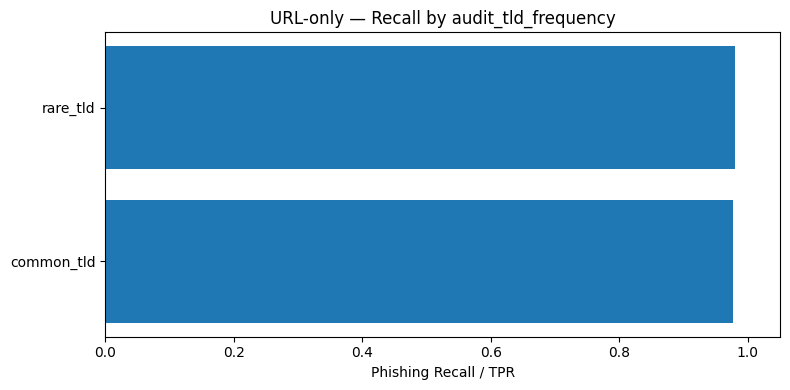

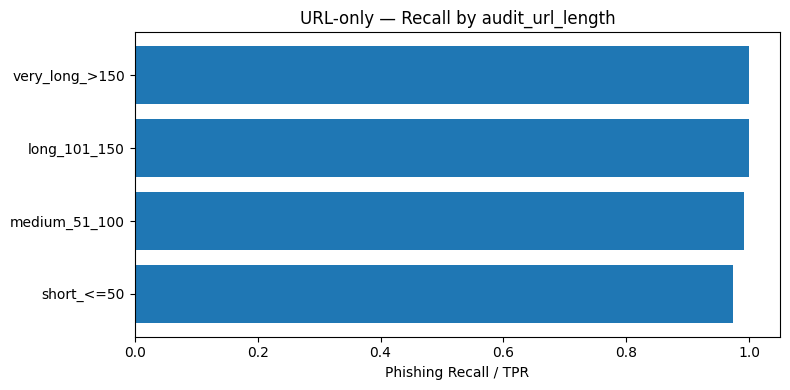

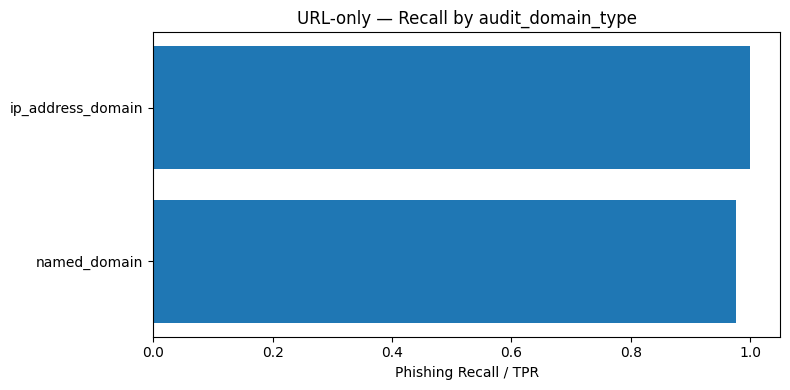

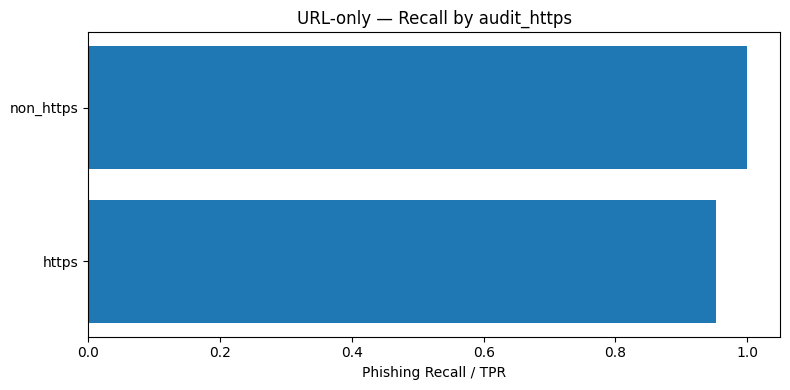

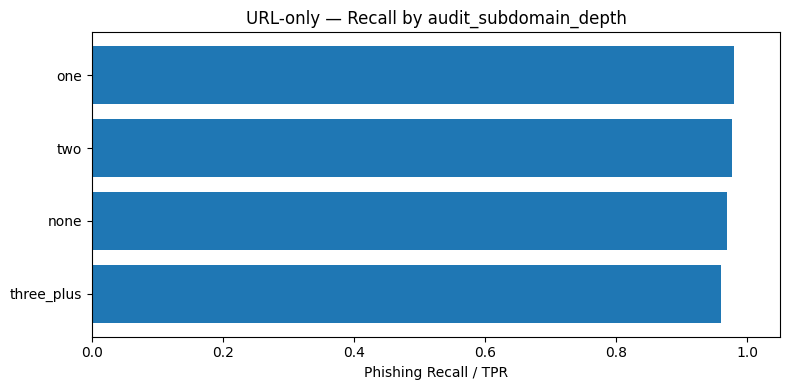

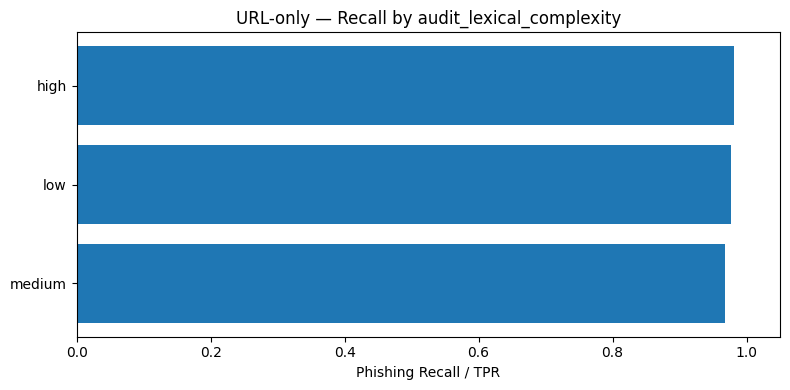

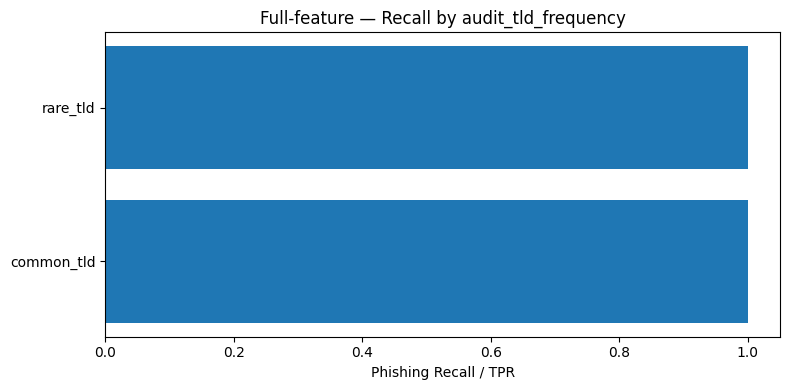

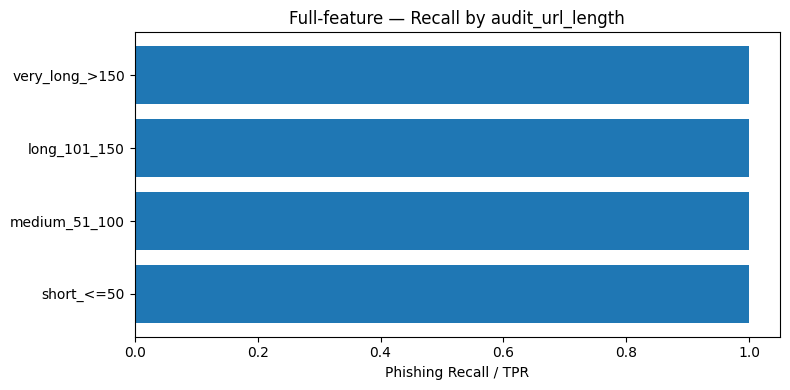

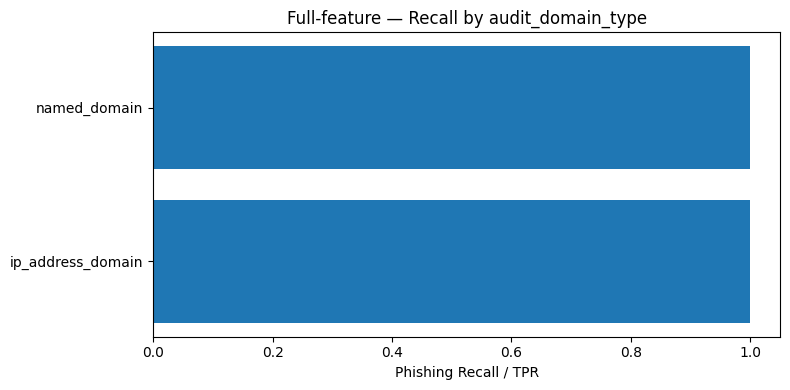

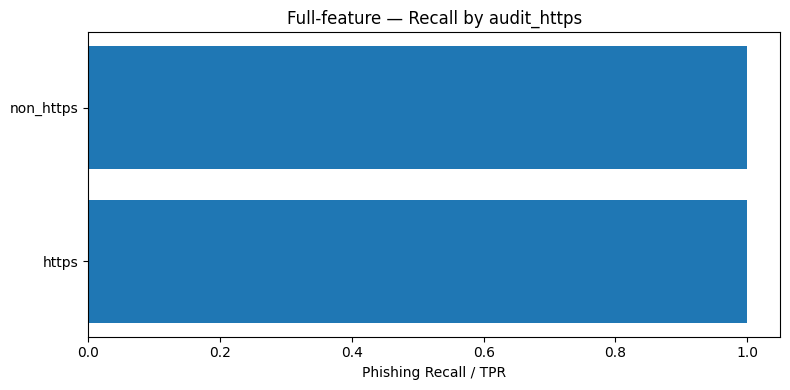

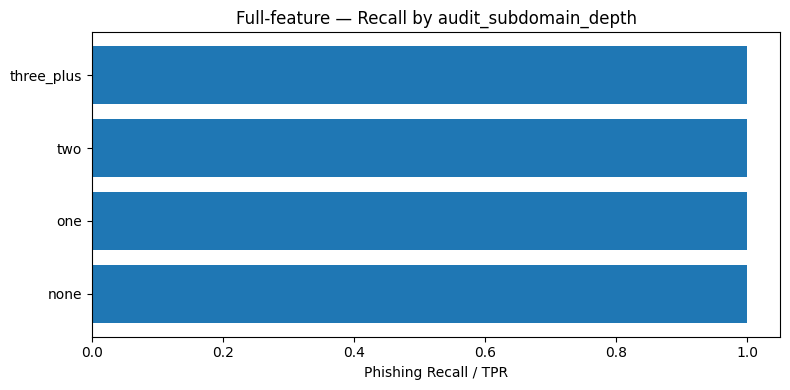

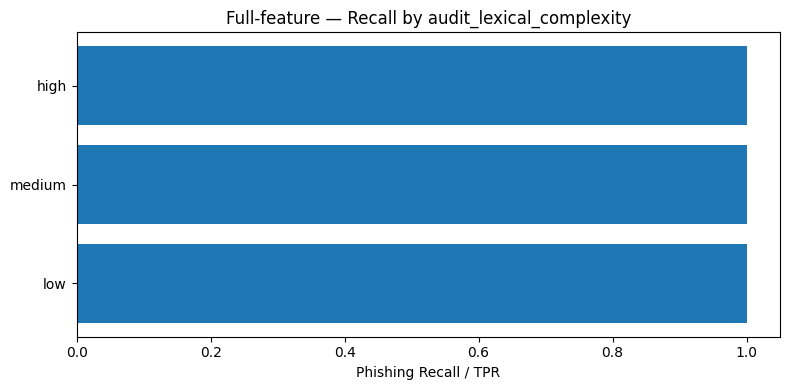

In [14]:
for experiment_name in subgroup_results[
    "experiment"
].unique():

    exp_data = subgroup_results.loc[
        subgroup_results["experiment"] == experiment_name
    ]

    for group_variable in exp_data[
        "group_variable"
    ].unique():

        plot_data = exp_data.loc[
            exp_data["group_variable"] == group_variable
        ].copy()

        plot_data = plot_data.sort_values(
            "recall_tpr"
        )

        fig, ax = plt.subplots(
            figsize=(8, max(4, 0.45 * len(plot_data)))
        )

        ax.barh(
            plot_data["group"],
            plot_data["recall_tpr"]
        )

        ax.set_xlim(0, 1.05)
        ax.set_xlabel("Phishing Recall / TPR")
        ax.set_title(
            f"{experiment_name} — Recall by {group_variable}"
        )

        plt.tight_layout()

        safe_exp = (
            experiment_name.lower()
            .replace("-", "_")
            .replace(" ", "_")
        )
        safe_group = (
            group_variable.lower()
            .replace(" ", "_")
        )

        plt.savefig(
            FIGURES_DIR
            / f"{safe_exp}_{safe_group}_recall.png",
            dpi=160,
            bbox_inches="tight"
        )

        plt.show()

## 5.13 Global Explainability — Permutation Importance

,feature,importance_mean,importance_std
6,LetterRatioInURL,0.115392,0.002492
12,NoOfOtherSpecialCharsInURL,0.067455,0.003781
34,eng_punctuation_ratio,0.044634,0.001953
41,eng_dataset_punctuation_total,0.038550,0.003805
8,DegitRatioInURL,0.034693,0.001957
25,eng_slash_count,0.022607,0.001156
32,eng_digit_letter_ratio,0.008740,0.000915
39,eng_uses_https,0.005384,0.000441
14,IsHTTPS,0.004596,0.000389
5,NoOfLettersInURL,0.003835,0.001047


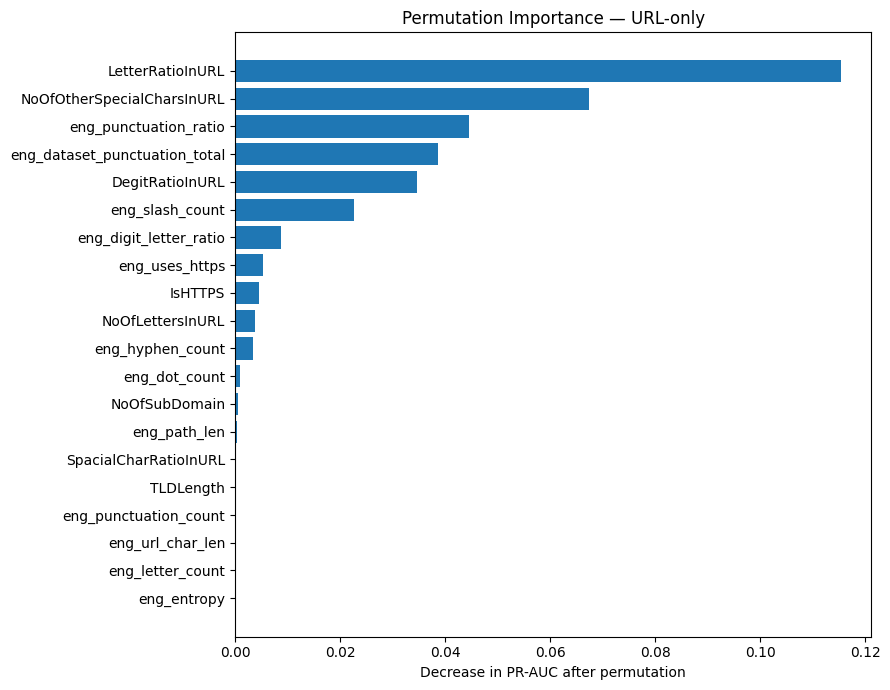

,feature,importance_mean,importance_std
3,URLSimilarityIndex,4.408491e-03,4.064523e-04
21,IsHTTPS,4.131522e-05,2.074159e-05
71,eng_uses_https,8.862302e-08,1.085406e-07
1,DomainLength,0.000000e+00,0.000000e+00
4,CharContinuationRate,0.000000e+00,0.000000e+00
2,IsDomainIP,0.000000e+00,0.000000e+00
6,URLCharProb,0.000000e+00,0.000000e+00
7,TLDLength,0.000000e+00,0.000000e+00
8,NoOfSubDomain,0.000000e+00,0.000000e+00
5,TLDLegitimateProb,0.000000e+00,0.000000e+00


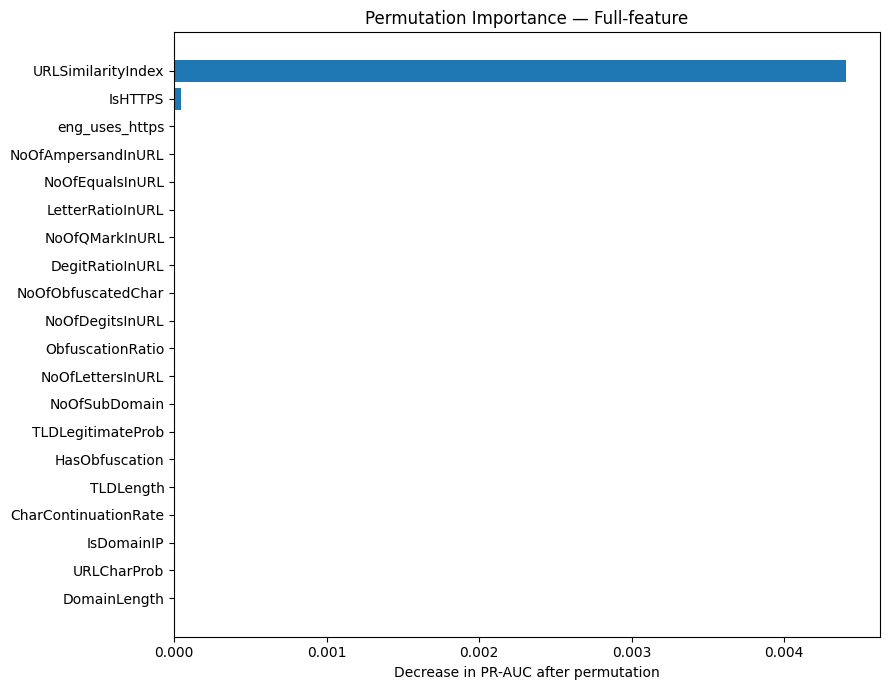

In [15]:
importance_tables = {}

for experiment_name, model in champion_models.items():

    features = (
        feature_schema["url_only_features"]
        if experiment_name == "URL-only"
        else feature_schema["full_numeric_features"]
    )

    # Use a manageable test sample for explainability.
    sample = test_df.sample(
        n=min(5000, len(test_df)),
        random_state=RANDOM_STATE
    )

    X_sample = sample[features].replace(
        [np.inf, -np.inf],
        np.nan
    )
    y_sample = sample[TARGET].astype(int)

    perm = permutation_importance(
        model,
        X_sample,
        y_sample,
        scoring="average_precision",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    table = pd.DataFrame({
        "feature": features,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values(
        "importance_mean",
        ascending=False
    )

    importance_tables[experiment_name] = table

    display(
        table.head(20)
    )

    table.to_csv(
        TABLES_DIR
        / f"{experiment_name.lower().replace('-', '_')}_permutation_importance.csv",
        index=False
    )

    plot_data = table.head(20).sort_values(
        "importance_mean"
    )

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(
        plot_data["feature"],
        plot_data["importance_mean"]
    )
    ax.set_xlabel("Decrease in PR-AUC after permutation")
    ax.set_title(
        f"Permutation Importance — {experiment_name}"
    )

    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR
        / f"{experiment_name.lower().replace('-', '_')}_permutation_importance.png",
        dpi=160,
        bbox_inches="tight"
    )
    plt.show()

## 5.14 SHAP Explainability


SHAP: URL-only


Background dataset has 800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=800 when initializing the masker.


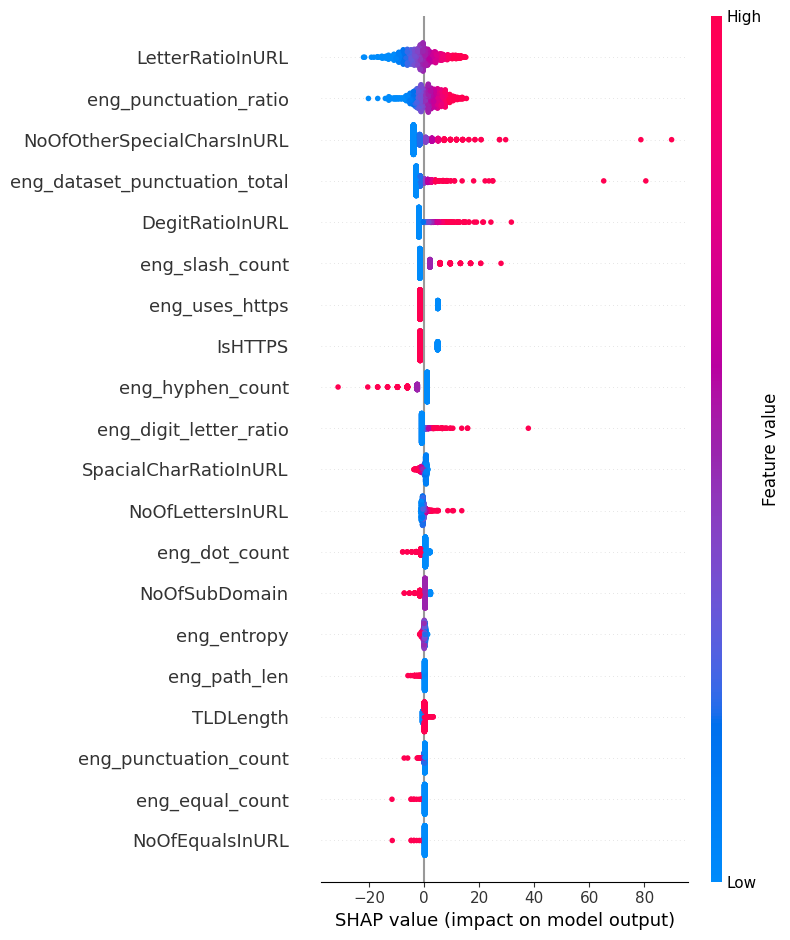

Background dataset has 800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=800 when initializing the masker.



SHAP: Full-feature


100%|===================| 1596/1600 [01:06<00:00]        

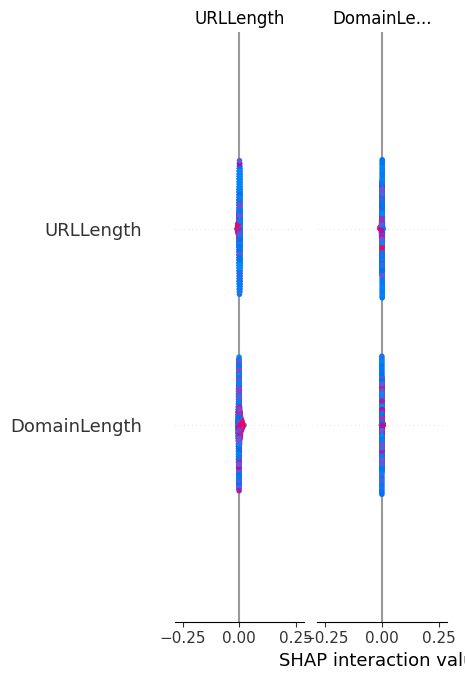

In [16]:
# Optional dependency:
# %pip install shap

def try_shap_analysis(
    experiment_name,
    model,
    features,
    data,
    max_rows=800
):
    try:
        import shap
    except ImportError:
        print(
            "SHAP is not installed. "
            "Run '%pip install shap' and rerun this cell."
        )
        return None

    sample = data.sample(
        n=min(max_rows, len(data)),
        random_state=RANDOM_STATE
    )

    X = sample[features].replace(
        [np.inf, -np.inf],
        np.nan
    )

    # Transform through every preprocessing step except final estimator.
    if hasattr(model, "named_steps"):
        transformer = model[:-1]
        estimator = model.named_steps["model"]

        X_transformed = transformer.transform(X)

        # For tree and linear estimators this usually works directly.
        try:
            explainer = shap.Explainer(
                estimator,
                X_transformed
            )
            shap_values = explainer(
                X_transformed
            )

            shap.summary_plot(
                shap_values,
                X_transformed,
                feature_names=features,
                show=True
            )

            return shap_values

        except Exception as exc:
            print(
                f"Direct SHAP analysis skipped for {experiment_name}:",
                repr(exc)
            )
            print(
                "Permutation importance remains available as the "
                "model-agnostic global explanation."
            )
            return None

    print(
        f"Unsupported model wrapper for automatic SHAP: {experiment_name}"
    )
    return None


for experiment_name, model in champion_models.items():
    features = (
        feature_schema["url_only_features"]
        if experiment_name == "URL-only"
        else feature_schema["full_numeric_features"]
    )

    print("\nSHAP:", experiment_name)

    _ = try_shap_analysis(
        experiment_name,
        model,
        features,
        test_df
    )

SHAP values describe **model contribution, not causation**. A large SHAP effect means the model relied heavily on a feature for a prediction; it does not prove that the feature causes phishing.

## 5.15 LIME Local Explanations

In [17]:
# Optional dependency:
# %pip install lime

def try_lime_example(
    experiment_name,
    model,
    features,
    train_data,
    test_data
):
    try:
        from lime.lime_tabular import LimeTabularExplainer
    except ImportError:
        print(
            "LIME is not installed. "
            "Run '%pip install lime' and rerun this cell."
        )
        return None

    X_train = (
        train_data[features]
        .replace([np.inf, -np.inf], np.nan)
        .copy()
    )

    X_test = (
        test_data[features]
        .replace([np.inf, -np.inf], np.nan)
        .copy()
    )

    # LIME requires finite numerical values.
    medians = X_train.median(
        numeric_only=True
    )

    X_train = X_train.fillna(medians)
    X_test = X_test.fillna(medians)

    # Choose one phishing observation where possible.
    candidate_index = test_data.index[
        test_data[TARGET] == 1
    ]

    if len(candidate_index) == 0:
        candidate_index = test_data.index

    chosen_index = candidate_index[0]

    local_row = X_test.loc[
        chosen_index
    ].values

    explainer = LimeTabularExplainer(
        training_data=X_train.sample(
            n=min(5000, len(X_train)),
            random_state=RANDOM_STATE
        ).values,
        feature_names=features,
        class_names=[
            "Legitimate",
            "Phishing"
        ],
        mode="classification",
        random_state=RANDOM_STATE
    )

    def lime_predict(arr):
        frame = pd.DataFrame(
            arr,
            columns=features
        )
        return model.predict_proba(frame)

    explanation = explainer.explain_instance(
        local_row,
        lime_predict,
        num_features=min(10, len(features))
    )

    lime_table = pd.DataFrame(
        explanation.as_list(),
        columns=["rule", "weight"]
    )

    display(lime_table)

    return lime_table


for experiment_name, model in champion_models.items():

    # LIME requires predict_proba.
    if not hasattr(model, "predict_proba"):
        print(
            experiment_name,
            "- LIME skipped because predict_proba is unavailable."
        )
        continue

    features = (
        feature_schema["url_only_features"]
        if experiment_name == "URL-only"
        else feature_schema["full_numeric_features"]
    )

    print("\nLIME:", experiment_name)

    lime_result = try_lime_example(
        experiment_name,
        model,
        features,
        train_df,
        test_df
    )

    if lime_result is not None:
        lime_result.to_csv(
            TABLES_DIR
            / f"{experiment_name.lower().replace('-', '_')}_lime_example.csv",
            index=False
        )


LIME: URL-only


,rule,weight
0,eng_slash_count <= 2.00,-0.360098
1,eng_host_is_ip <= 0.00,0.256177
2,IsDomainIP <= 0.00,0.253556
3,DegitRatioInURL <= 0.00,-0.229766
4,eng_hyphen_count <= 0.00,0.190988
5,HasObfuscation <= 0.00,0.168970
6,NoOfObfuscatedChar <= 0.00,-0.150975
7,eng_at_count <= 0.00,0.118279
8,eng_query_len <= 0.00,0.108668
9,ObfuscationRatio <= 0.00,-0.019474



LIME: Full-feature


,rule,weight
0,eng_slash_count <= 2.00,-0.110128
1,eng_path_len <= 0.00,-0.102258
2,URLSimilarityIndex <= 57.18,0.077724
3,HasObfuscation <= 0.00,-0.065458
4,LineOfCode <= 16.00,0.040695
5,NoOfObfuscatedChar <= 0.00,0.039195
6,eng_log1p_LineOfCode <= 2.83,0.033194
7,eng_path_depth <= 0.00,-0.028913
8,ObfuscationRatio <= 0.00,-0.027425
9,eng_percent_count <= 0.00,0.025405


## 5.16 PDP and ICE Analysis

URL-only PDP/ICE features: ['LetterRatioInURL', 'NoOfOtherSpecialCharsInURL', 'eng_punctuation_ratio']


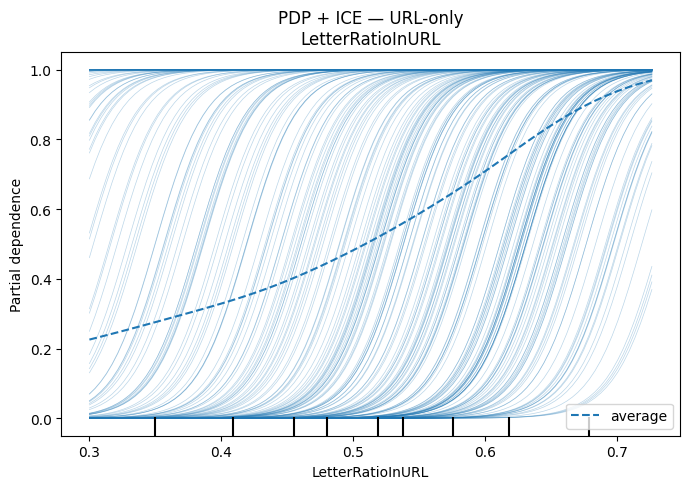

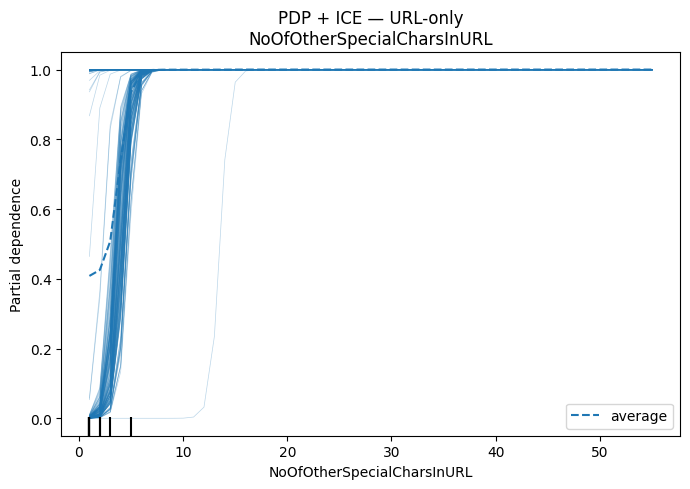

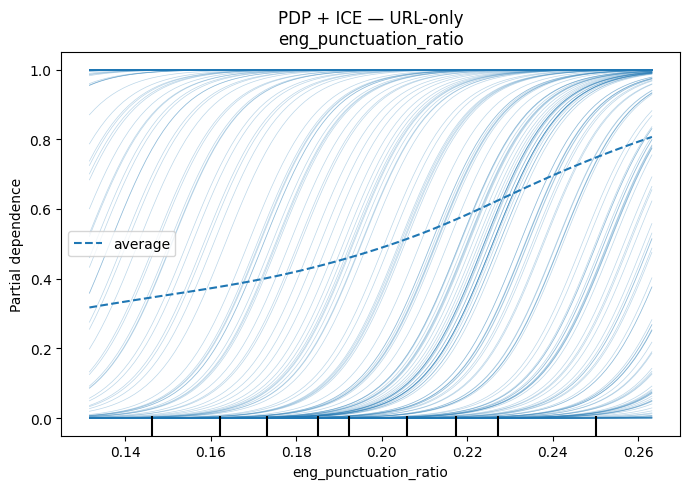

Full-feature PDP/ICE features: ['URLSimilarityIndex', 'IsHTTPS', 'eng_uses_https']


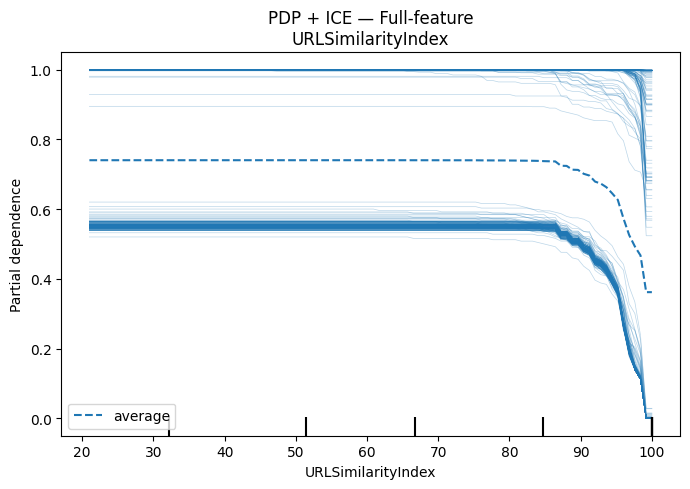

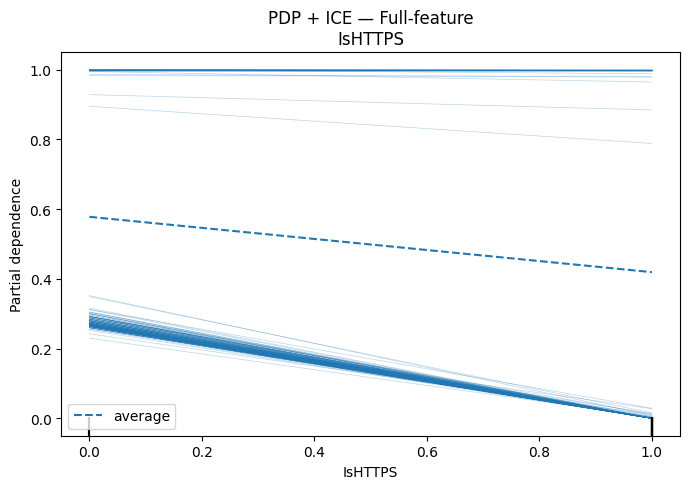

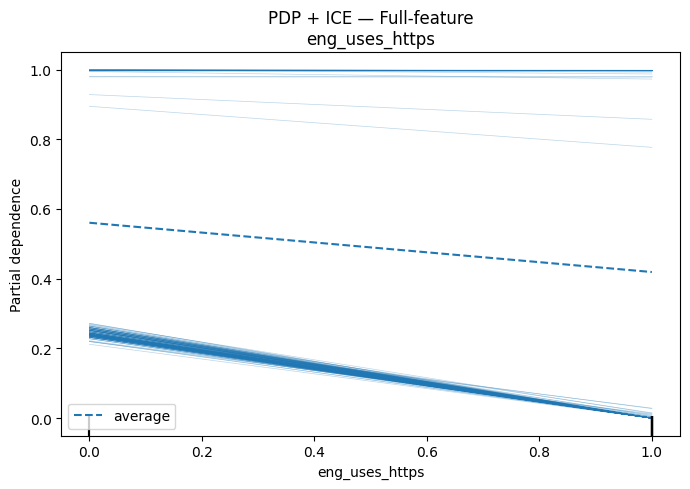

In [18]:
for experiment_name, model in champion_models.items():

    features = (
        feature_schema["url_only_features"]
        if experiment_name == "URL-only"
        else feature_schema["full_numeric_features"]
    )

    # Select top permutation-important features.
    top_features = (
        importance_tables[experiment_name]
        .head(3)["feature"]
        .tolist()
    )

    X_plot = (
        test_df[features]
        .sample(
            n=min(3000, len(test_df)),
            random_state=RANDOM_STATE
        )
        .replace([np.inf, -np.inf], np.nan)
    )

    print(
        experiment_name,
        "PDP/ICE features:",
        top_features
    )

    for feature in top_features:
        try:
            fig, ax = plt.subplots(
                figsize=(7, 5)
            )

            PartialDependenceDisplay.from_estimator(
                model,
                X_plot,
                [feature],
                kind="both",
                subsample=250,
                random_state=RANDOM_STATE,
                ax=ax
            )

            ax.set_title(
                f"PDP + ICE — {experiment_name}\n{feature}"
            )

            plt.tight_layout()

            safe_exp = (
                experiment_name.lower()
                .replace("-", "_")
            )
            safe_feature = (
                feature.lower()
                .replace("/", "_")
            )

            plt.savefig(
                FIGURES_DIR
                / f"{safe_exp}_pdp_ice_{safe_feature}.png",
                dpi=160,
                bbox_inches="tight"
            )

            plt.show()

        except Exception as exc:
            print(
                f"PDP/ICE skipped for {feature}:",
                repr(exc)
            )

## 5.17 False Positive and False Negative Case Analysis

In [19]:
error_case_tables = {}

for experiment_name, audit in audit_frames.items():

    audit = audit.copy()

    false_positive = audit.loc[
        (audit[TARGET] == 0)
        & (audit["model_prediction"] == 1)
    ].copy()

    false_negative = audit.loc[
        (audit[TARGET] == 1)
        & (audit["model_prediction"] == 0)
    ].copy()

    error_case_tables[
        f"{experiment_name}_false_positive"
    ] = false_positive

    error_case_tables[
        f"{experiment_name}_false_negative"
    ] = false_negative

    print("\n", experiment_name)
    print("False positives:", len(false_positive))
    print("False negatives:", len(false_negative))

    columns_to_show = [
        c for c in [
            "URL",
            "Domain",
            "TLD",
            "URLLength",
            "IsHTTPS",
            "IsDomainIP",
            "model_score"
        ]
        if c in audit.columns
    ]

    if len(false_positive):
        print("Example false positives:")
        display(
            false_positive[
                columns_to_show
            ].head(5)
        )

    if len(false_negative):
        print("Example false negatives:")
        display(
            false_negative[
                columns_to_show
            ].head(5)
        )


 URL-only
False positives: 0
False negatives: 335
Example false negatives:


,URL,Domain,TLD,URLLength,IsHTTPS,IsDomainIP,model_score
332,https://www.faewood.com,www.faewood.com,com,23,1,0,0.005464
1599,https://www.ioginunlcovlabcp.com/,www.ioginunlcovlabcp.com,com,32,1,0,0.878677
2458,https://www.cc836593.com,www.cc836593.com,com,23,1,0,0.580892
3691,https://pastseveralparallelport--reloadtivebip...,pastseveralparallelport--reloadtivebip.repl.co,co,53,1,0,0.960768
4084,https://www.ridm.in,www.ridm.in,in,18,1,0,0.000179



 Full-feature
False positives: 0
False negatives: 0


## 5.18 Mitigation Experiment — Threshold Sensitivity

In [20]:
threshold_analysis_rows = []

for experiment_name, audit in audit_frames.items():

    selected_threshold = float(
        champions[experiment_name]["threshold"]
    )

    y_true = audit[TARGET].astype(int).values
    scores = audit["model_score"].values

    # Evaluate relative thresholds around the chosen operating point.
    candidate_thresholds = sorted(set([
        max(0.0, selected_threshold * 0.50),
        max(0.0, selected_threshold * 0.75),
        selected_threshold,
        min(1.0, selected_threshold * 1.10),
        min(1.0, selected_threshold * 1.25),
    ]))

    for threshold in candidate_thresholds:

        y_pred = threshold_predictions(
            scores,
            threshold
        )

        threshold_analysis_rows.append({
            "experiment": experiment_name,
            "threshold": threshold,
            "precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "recall": recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "f1": f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "false_positive_rate": false_positive_rate(
                y_true,
                y_pred
            ),
            "predicted_positive_rate": y_pred.mean()
        })

threshold_sensitivity = pd.DataFrame(
    threshold_analysis_rows
)

display(
    threshold_sensitivity.round(6)
)

threshold_sensitivity.to_csv(
    TABLES_DIR / "threshold_sensitivity.csv",
    index=False
)

,experiment,threshold,precision,recall,f1,false_positive_rate,predicted_positive_rate
0,URL-only,0.498436,0.999861,0.993161,0.996499,0.000099,0.413660
1,URL-only,0.747655,0.999930,0.992608,0.996256,0.000049,0.413401
2,URL-only,0.996873,1.000000,0.976857,0.988293,0.000000,0.406813
3,URL-only,1.000000,1.000000,0.056235,0.106482,0.000000,0.023419
4,Full-feature,0.154169,0.999517,1.000000,0.999758,0.000345,0.416652
5,Full-feature,0.231254,0.999793,1.000000,0.999896,0.000148,0.416537
6,Full-feature,0.308339,1.000000,1.000000,1.000000,0.000000,0.416451
7,Full-feature,0.339173,1.000000,1.000000,1.000000,0.000000,0.416451
8,Full-feature,0.385424,1.000000,1.000000,1.000000,0.000000,0.416451


Threshold adjustment can mitigate the trade-off between missed phishing and legitimate URLs incorrectly flagged. It should be treated as an operational policy decision, not as a way to conceal poor model performance.